Ablation Study Data Ready:


,Configuration,Recall@1,Recall@5,Recall@10,MRR
0,"Baseline (64d, Mean, EdgeDrop)",12.16,30.79,42.23,0.2021
1,"Max+Mean (256d, FeatMask)",9.58,25.09,34.65,0.1626
2,"Mean Only (256d, FeatMask)",0.00,0.00,0.00,0.0000


C:\Users\di_li\AppData\Local\Temp\ipykernel_4880\641009210.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


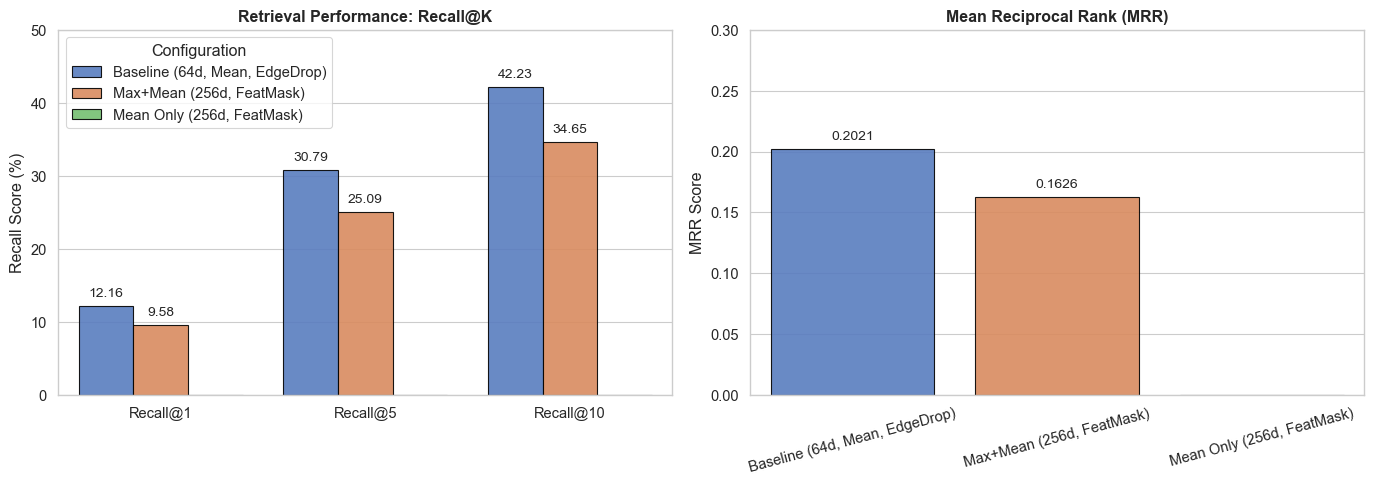


Plots successfully generated and saved as 'ablation_study_results.png' and '.pdf'!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. Ablation Study Data
# ==========================================
# Case 1: Baseline
# Case 2: Max+Mean Pool
# Case 3: Mean Pool Only

data = [
    {
        "Configuration": "Baseline (64d, Mean, EdgeDrop)", 
        "Recall@1": 12.16, "Recall@5": 30.79, "Recall@10": 42.23, "MRR": 0.2021
    },
    {
        "Configuration": "Max+Mean (256d, FeatMask)", 
        "Recall@1": 9.58,  "Recall@5": 25.09, "Recall@10": 34.65, "MRR": 0.1626
    },
    {
        "Configuration": "Mean Only (256d, FeatMask)", 
        "Recall@1": 7.19,  "Recall@5": 20.13,  "Recall@10": 28.61,  "MRR": 0.1283 

    }
]

df = pd.DataFrame(data)
print("Ablation Study Data Ready:")
display(df)

# ==========================================
# 2. Visualization
# ==========================================

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------
# First plot: Recall@K
# ------------------------------------------
df_recall = df.melt(id_vars=["Configuration"], 
                    value_vars=["Recall@1", "Recall@5", "Recall@10"], 
                    var_name="Metric", value_name="Score (%)")

sns.barplot(
    data=df_recall, 
    x="Metric", y="Score (%)", hue="Configuration", 
    ax=axes[0], palette="muted", edgecolor="black", alpha=0.9
)
axes[0].set_title("Retrieval Performance: Recall@K", fontweight='bold')
axes[0].set_ylabel("Recall Score (%)")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 50)


for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(format(p.get_height(), '.2f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), textcoords = 'offset points', fontsize=10)

# ------------------------------------------
# Second plot: MRR
# ------------------------------------------
sns.barplot(
    data=df, 
    x="Configuration", y="MRR", 
    ax=axes[1], palette="muted", edgecolor="black", alpha=0.9
)
axes[1].set_title("Mean Reciprocal Rank (MRR)", fontweight='bold')
axes[1].set_ylabel("MRR Score")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 0.3)

axes[1].tick_params(axis='x', rotation=15)

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(format(p.get_height(), '.4f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), textcoords = 'offset points', fontsize=10)


plt.tight_layout()

# plt.savefig("ablation_study_results.png", dpi=300, bbox_inches='tight')
# plt.savefig("ablation_study_results.pdf", bbox_inches='tight') 
plt.show()

print("\nPlots successfully generated and saved as 'ablation_study_results.png' and '.pdf'!")